# **Loan Approval Explainability Analysis**


- Part 1: Data Preparation
- Part 2: Model Building
- Part 3: SHAP Explanations (Begin Assignment 5.1)

## **Part 1: Data Preparation**

In [ ]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv(r"loan_approval_biased.csv")

# data exploration
df.info()  # Check for missing values and data types
print(df.head(20))
df.describe()

# Print the counts
#Count the number of males and females in the dataset
gender_counts = df['Gender'].value_counts()

# Print the counts
print("\nCounts of each gender in the dataset")
print(gender_counts)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    int64  
 3   Dependents         614 non-null    int64  
 4   Education          614 non-null    int64  
 5   Self_Employed      614 non-null    int64  
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    int64  
 9   Loan_Amount_Term   614 non-null    int64  
 10  Credit_History     614 non-null    int64  
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    object 
dtypes: float64(1), int64(9), object(3)
memory usage: 62.5+ KB
     Loan_ID  Gender  Married  Dependents  Education  Self_Employed  \
0   LP002317    Male        1           3

### **Prepare Data for Logistic Regression:**

- Convert Loan_Status to binary (1 for Y, 0 for N)
- Convert Gender column to binary (1 for Male, 0 for Female)
- Define the preprocessor with OneHotEncoder for remaining categorical features


In [ ]:
# Convert Loan_Status to binary (1 for Y, 0 for N)
df['Loan_Status'] = df['Loan_Status'].apply(lambda x: 1 if x == 'Y' else 0)

# Define categorical and numerical columns
categorical_columns = ['Married', 'Dependents', 'Self_Employed', 'Property_Area','Gender']
numerical_columns = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

# Convert Gender column to binary (1 for Male, 0 for Female)
df['Gender'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0)

# Define the preprocessor with OneHotEncoder for remaining categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_columns),
        ('num', StandardScaler(), numerical_columns)
    ])

# Split the data into features and target
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

# Apply the preprocessor on the full dataset
X_transformed = preprocessor.fit_transform(X)

# Convert the transformed data back into a df
transformed_feature_names = preprocessor.get_feature_names_out()
X_transformed_df = pd.DataFrame(X_transformed, columns=transformed_feature_names)

# Display the transformed data
print(X_transformed_df.head())



   cat__Married_0  cat__Married_1  cat__Dependents_0  cat__Dependents_1  \
0             0.0             1.0                0.0                0.0   
1             0.0             1.0                1.0                0.0   
2             0.0             1.0                0.0                0.0   
3             0.0             1.0                1.0                0.0   
4             1.0             0.0                0.0                1.0   

   cat__Dependents_2  cat__Dependents_3  cat__Self_Employed_0  \
0                0.0                1.0                   1.0   
1                0.0                0.0                   1.0   
2                0.0                1.0                   1.0   
3                0.0                0.0                   0.0   
4                0.0                0.0                   1.0   

   cat__Self_Employed_1  cat__Property_Area_0  cat__Property_Area_1  \
0                   0.0                   1.0                   0.0   
1               

In [ ]:
#  Count the number of approved loans for each gender
# Filter for approved loans
approved_loans = df[df['Loan_Status'] == 1]

gender_approval_counts = approved_loans['Gender'].value_counts()

print(gender_approval_counts)

Gender
1    217
0      3
Name: count, dtype: int64


## **Part 2: Model Building**

In [ ]:
# stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit the preprocessor on training data
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Create the pipeline with a logistic regression model
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=10000))
])

# Fit the model
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['Married', 'Dependents',
                                                   'Self_Employed',
                                                   'Property_Area', 'Gender']),
                                                 ('num', StandardScaler(),
                                                  ['ApplicantIncome',
                                                   'CoapplicantIncome',
                                                   'LoanAmount',
                                                   'Loan_Amount_Term',
                                                   'Credit_History'])])),
                ('classifier', LogisticRegression(max_iter=10000))])

In [ ]:
# Predict on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9106
Precision: 0.9231
Recall: 0.8182
F1 Score: 0.8675


**Expected Output:**

- Logistic regression model should fit to the training data successfully.


*********

# **Begin Assignment 5.1**

## In this exercise, you will analyze the loan approval dataset and utilize SHAP to understand feature contributions to model predictions. The goal is to interpret how specific features affect decisions and reflect on the ethical implications of such models.


## **Part 3: SHAP Explanations**

In [ ]:
# Explaining model predictions using SHAP
# Take a sample of the training data for SHAP
X_sample = shap.sample(X_train, 100)

# Create the SHAP explainer
explainer = shap.Explainer(model.predict_proba, X_sample)

# Get SHAP values for the test set
shap_values = explainer(X_test)

PermutationExplainer explainer: 124it [00:27,  3.43it/s]


### **Question 1a. Use SHAP to understand how individual features contribute to the prediction for a specific data point with a force plot that visualizes the feature contributions for a particular class.**

#### <b> Instructions </b>
- Generate the <b> SHAP force plot </b> for the first data point in your test set using the SHAP values.
- The force plot should explain how individual features contribute to pushing the model's prediction towards or away from <b> class 1 </b>.
- Make sure to use SHAP values corresponding to class 1 for the <b> first data point </b> in the test set.


In [ ]:
# Javascript required for force plot
shap.initjs()

# Force plot
first_data_point = X_test.iloc[0]
shap_values_class1 = shap_values.values[0, :, 1]
expected_value_class1 = shap_values.base_values[0, 1]

shap.plots.force(
    base_value=expected_value_class1,
    shap_values=shap_values_class1,
    features=first_data_point
)

### **Question 1b. Which features are pushing the prediction towards class 1? Which features are pushing the prediction away from class 1?**

- The credit History feature is pushing the prediction towards class 1.
- And the Gender feature is pushing the prediction away from class 1.

### **Question 2a. Create a bar plot that displays the SHAP values (feature contributions) for the second data point and SHAP values for class 1. The bar plot will show how much each feature contributes to the model's prediction for class 1, with the features ranked by their contribution.)**

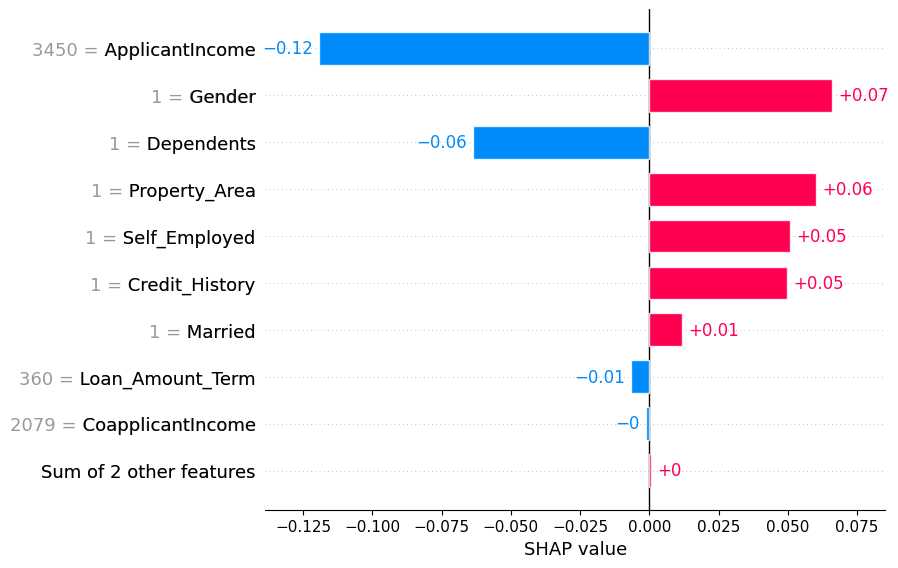

In [ ]:
# SHAP Bar plot
shap.plots.bar(
    shap_values[1,:, 1]
)

### **Question 2b. Which feature had the greatest influence on the prediction for this data point? Were most features pushing the prediction toward or away from class 1? Are there any surprising variables that are influencing the prediction?**

**Features pushing towards class 1**
Listed features increase the models predicted probability for class 1.
- Property_Area --> +.0.06 is strong contributor
- Self_Employed --> + 0.05
- Credit_History --> + 0.05 .

**Features pushing away from class 1**
Load_Amount _Term and CoapplicantIncome has negative SHAP values, ie it reduces the probability of class 1.

### **Question 3a.Create a beeswarm plot that visualizes the global importance of features for class 1 (positive class) across all data points. You will use this plot to identify which features consistently influence the model's prediction.**

#### **Instructions**
The beeswarm plot should display the SHAP values for <b> class 1</b> across all data points in the test set.

   Note: Features will be sorted by their importance, with the most influential features appearing at the top.


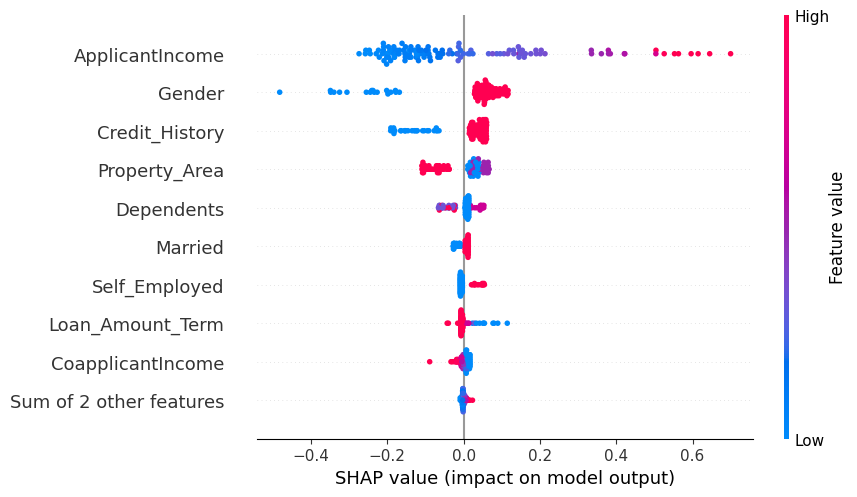

In [ ]:
# Beeswarm plot
shap.plots.beeswarm(
    shap_values[:, :, 1]
)

### **Question 3b. Which feature appears to be the most important across all data points? Are there any features that have a mixed effect (i.e. pushing predictions towards class 1 and other times pushing them away?) What could cause this variability? How do the color of the dots help you interpret the relationship between the feature value and the prediction? Are there any notable findings?**

1. Most Important Feature
The features are ordered by their total impact on the model. ApplicantIncome is the most important feature.

Reasoning: It has the widest horizontal spread of SHAP values. The dots for ApplicantIncome range from approximately -0.25 to +0.70, indicating it has the largest influence (both positive and negative) on the final prediction compared to any other variable.

2. Features with a Mixed Effect
A "mixed effect" occurs when dots for a single feature are scattered on both the left (negative SHAP) and right (positive SHAP) sides of the center vertical line. Several features show this:

ApplicantIncome: High values (pink) strongly push the prediction toward Class 1, while low values (blue) push it away.

Property_Area: You can see distinct clusters on both sides of the zero line.

Loan_Amount_Term: While the impact is small, the dots are distributed on both sides.

What causes this variability?
Variability is caused by Feature Interactions. The impact of a feature often depends on the values of other features. For example, a high ApplicantIncome might push a prediction toward "Approved" (+ SHAP), but if the Credit_History is poor or the LoanAmount is excessively high, that same income might have a different or muted effect within the model's logic.

3. Interpreting the Colors
The color scale represents the original value of the feature for that specific data point:

Pink/Red (High): Represents a high numerical value (e.g., high income).

Blue (Low): Represents a low numerical value (e.g., low income).

Relationship Interpretation:
By looking at the color and the position, you can determine the direction of the relationship:

Positive Correlation: For ApplicantIncome, the pink dots are on the right. This tells us that higher income leads to a higher probability of Class 1 (Approval).

Negative Correlation: For Property_Area, the pink dots are mostly on the left. This suggests that "higher" values in this encoded category actually decrease the probability of approval.

4. Notable Findings
Gender Bias: Gender appears as the second most influential feature. The thick cluster of pink (high) dots on the positive side suggests that the model's output is significantly influenced by this attribute. In an ethical AI context, this is a major red flag for algorithmic bias, as a protected characteristic is driving the decision.

Credit History: Interestingly, Credit_History shows a very tight, binary-like cluster. Low values (blue) are on the negative side, and high values (pink) are on the positive side, confirming that a "good" credit history is a consistent, positive predictor.

The "Long Tail" of Income: Notice the sparse pink dots stretching far to the right (up to +0.7). This represents "outlier" high-income earners who have an exceptionally high influence on their own approval probability.

## **Part 4: Ethical Reflection**


As you explored the SHAP plots, you were able to see how individual featuers contribute to a model's predictions, increasing transparency. However, even with these interpretability tools, there are broader ethical concerns regarding bias and transparency in machine learning systems.

Machine learning models, particularly those used in high-stakes areas like healthcare, finance, and criminal justice, can inadvertently reinforce societal biases present in the training data (e.g., based on race, gender, income). While tools like SHAP provide insights into how models make decisions, they do not prevent biased outcomes.





**Question 1: How can explainability tools such as SHAP help identify bias in machine learning models?**


**Question 2: How does explainability contribute to transparency in machine learning systems?**
